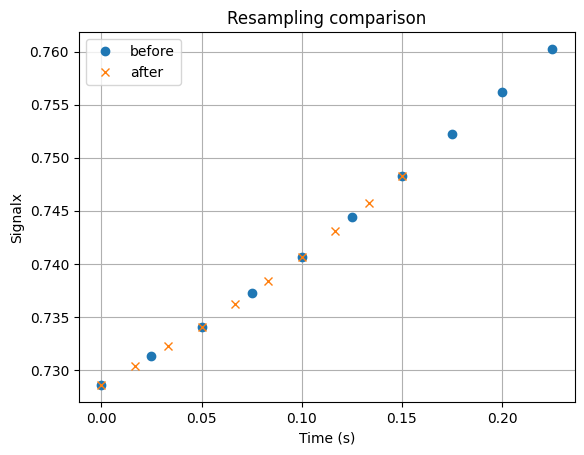

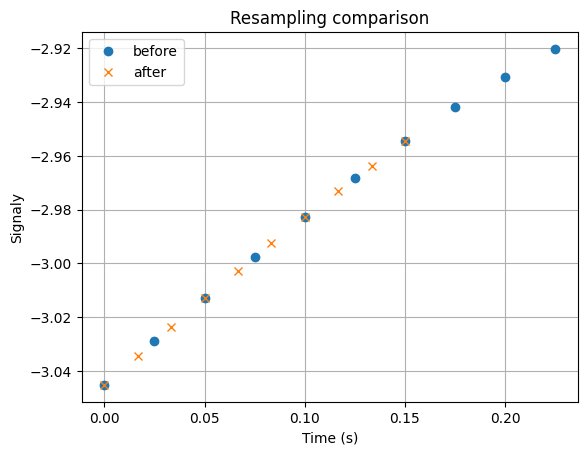

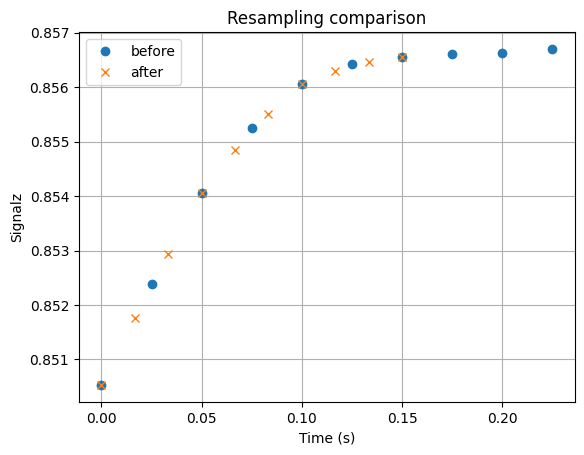

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing.resample import resample_timeseries
from src.io.helpers.helpers_my_signal import get_signal
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

def __plot_resampled_timestamp(orig_signal: np.ndarray, resampled_signal: np.ndarray, orig_time, res_time, title: str = "Before vs After") :
    orig_signal = np.asarray(orig_signal, dtype=float)
    resampled_signal = np.asarray(resampled_signal, dtype=float)

    #if orig_signal.shape != resampled_signal.shape:
        #raise ValueError(f"Shape mismatch: raw {orig_signal.shape}, filtered {resampled_signal.shape}")


    n_frames, n_dims = orig_signal.shape
    labels = ["x", "y", "z"][:n_dims]
    if n_dims > 3:
        labels = [f"dim_{i}" for i in range(n_dims)]

    #t = np.arange(n_frames)

    #fig, axes = plt.subplots(n_dims, 1, figsize=(14, 1 * n_dims), sharex=True)

    if n_dims == 1:
        axes = np.array([axes])

    for i in range(n_dims):
        #axes[i, 0].plot(orig_time, orig_signal[:, i], '--', label="before", linewidth=2, alpha=1.0)
        #axes[i, 0].plot(t, filtered[:, i], marker='o', label="after", alpha= 0.7)
        #axes[i, 0].set_ylabel(labels[i])
        #axes[i, 0].set_title(f"{labels[i]}: before")
        #axes[i, 0].grid(True)
        #axes[i, 0].legend()

        #axes[i, 1].plot(res_time, resampled_signal[:, i],'-', label="after", alpha= 0.7)
        #axes[i, 1].set_title(f"{labels[i]}: after")
        #axes[i, 1].grid(True)
        #axes[i, 1].legend()

        plt.figure()
        plt.plot(orig_time[:10], orig_signal[:10, i], marker='o', linestyle='None', label="before")
        plt.plot(res_time[:10], resampled_signal[:10, i], marker='x', linestyle='None', label = "after")
        plt.xlabel("Time (s)")
        plt.ylabel(f"Signal{labels[i]}")
        plt.title("Resampling comparison")
        plt.grid(True)
        plt.legend()
        plt.show()


    #axes[-1, 0].set_xlabel("Time Stamp")
    #axes[-1, 1].set_xlabel("Time Stamp")
    #fig.suptitle(title)
   # plt.tight_layout()
    #plt.show()    


path = Path("../tests/sample_data/sample_xsens.csv")
signal = get_signal(path)

target_signal, orig_time, res_time = resample_timeseries(signal, orig_fps=40, target_fps=60)
__plot_resampled_timestamp(signal, target_signal, orig_time, res_time, title="Resample Timestamp")
